In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-07 02:35:08.975 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.experts.tapas import lock_right as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 3, 4, 5]

2026-07-07 02:35:10.588 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-07 02:35:12.210 | INFO     | heca.misc.logger:info:30 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_right_button
2026-07-07 02:35:12.210 | INFO     | tapas_gmm_modified.utils.logging:wrapper:67 - Initializing Policy:
2026-07-07 02:35:12.210 | INFO     | tapas_gmm_modified.encoder:get_image_encoder_class:62 - No encoder config provided. Using None.
2026-07-07 02:35:12.210 | WARNING  | heca.misc.logger:warning:26 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_right_button/policy_gt.pt
GMMPolicy(
  (obs_encoder): ObservationEncoder()
)
[[0, 3], [3, 7]]


In [3]:
observations = agent.load_demos(selections)

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


2026-07-07 02:35:20.212 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
n_trajs 5
n_frames 8


('ee_init',
 'block_0',
 'button_0',
 'button_1',
 'drawer_handle',
 'window_handle',
 'block_0_target',
 'ee_target')

2026-07-07 02:35:20.218 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:35:20.218 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:20.218 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


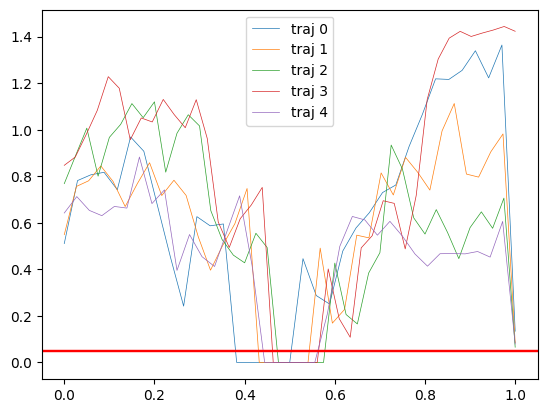

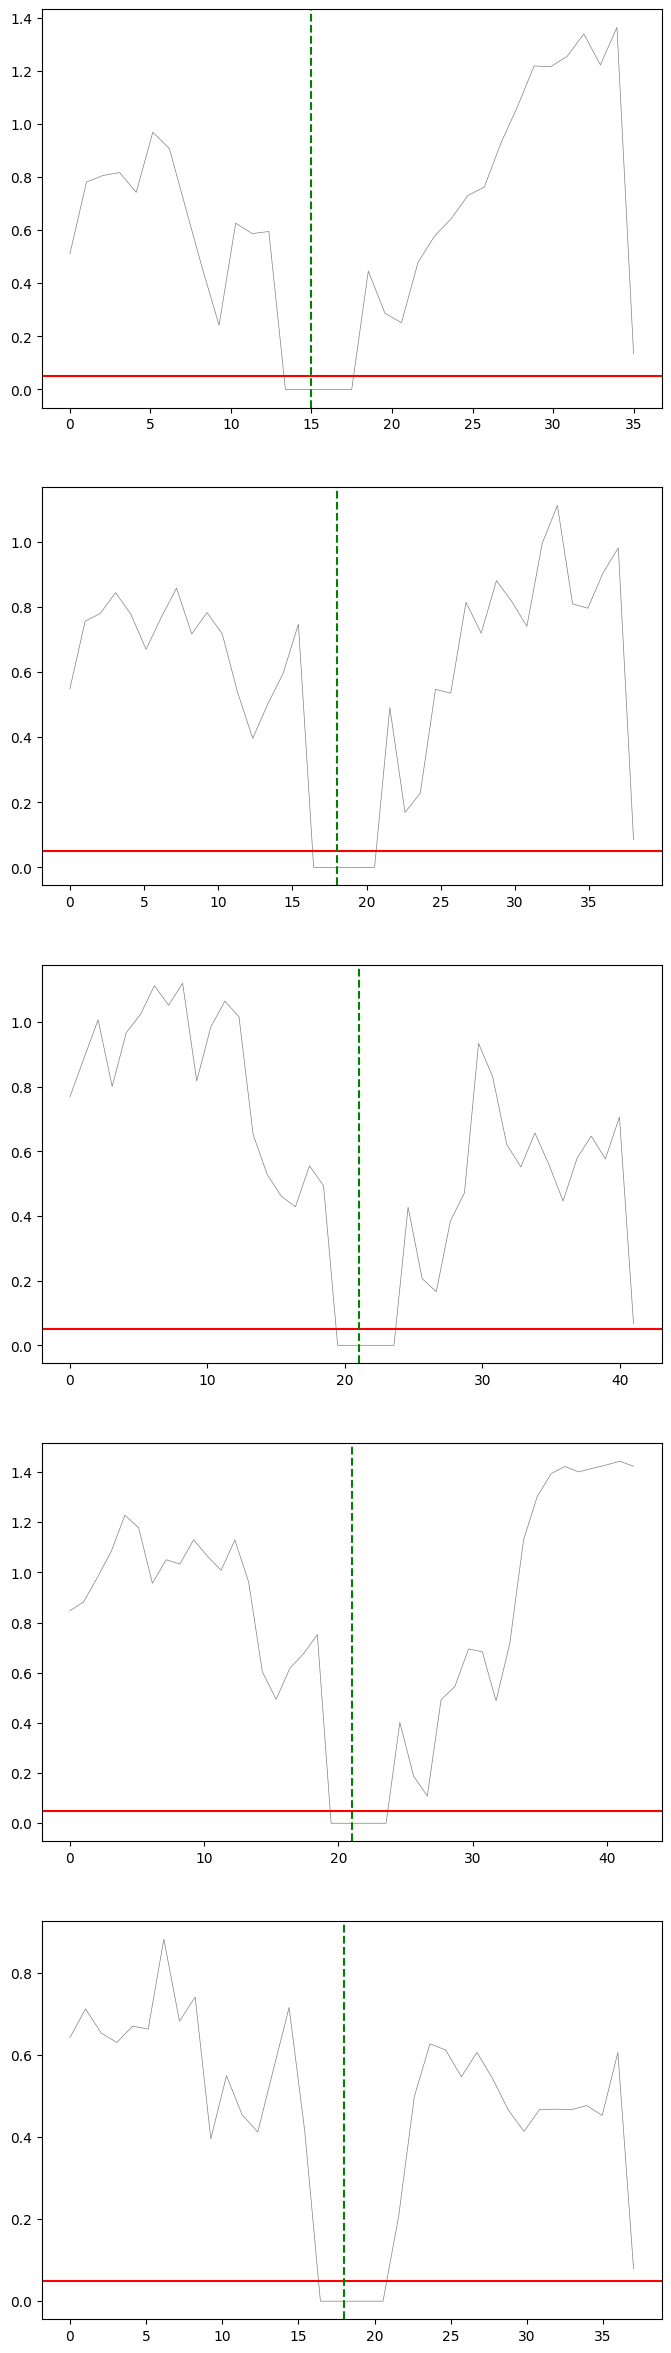

2026-07-07 02:35:20.488 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:35:20.489 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:35:20.489 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 02:35:20.490 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 20 using strategy mean-length.
2026-07-07 02:35:20.490 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 2 segments
2026-07-07 02:35:20.490 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 1/8
2026-07-07 02:35:20.490 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:20.490 | INFO     | tapas_gmm_modified.dataset.demos:subsample_t

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:20.536 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-07-07 02:35:20.536 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:20.536 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:35:20.539 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:35:20.539 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:20.539 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:20.539 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:20.600 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-07-07 02:35:20.600 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:35:20.600 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 18 using strategy mean-length.
2026-07-07 02:35:20.603 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 02:35:20.603 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:20.603 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:20.603 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-07-07 02:35:21.776 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:35:21.776 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:35:21.776 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:21.776 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 02:35:21.894 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 02:35:21.895 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:35:21.895 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 02:35:21.895 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/10 [00:00<?, ?it/s]

((array([[2.70e+012, 3.83e+012, 3.58e+010, 9.12e+009, 2.08e+005, 2.12e+001,
          4.08e-009, 2.63e-021, 1.70e-032, 1.23e-034, 1.74e-045, 1.96e-056,
          8.78e-064, 4.12e-072, 1.29e-083, 1.50e-089, 7.09e-100, 3.45e-107,
          1.34e+013, 9.04e+012, 1.03e+012, 2.38e+010, 2.78e+007, 4.26e+004,
          3.82e+000, 1.21e-006, 1.99e-014, 4.13e-023, 1.33e-030, 3.51e-037,
          3.45e-043, 3.84e-049, 1.26e-055, 3.29e-062, 2.84e-068, 3.42e-075,
          2.87e+012, 4.42e+012, 2.52e+011, 1.38e+006, 7.03e+000, 4.34e-007,
          3.91e-016, 5.19e-026, 6.92e-037, 2.43e-065, 1.36e-080, 1.20e-094,
          2.74e-107, 2.17e-123, 5.90e-139, 3.83e-171, 9.66e-190, 5.31e-196,
          2.60e+012, 2.91e+012, 2.96e+011, 6.37e+007, 5.77e+003, 3.72e-002,
          4.18e-008, 5.53e-016, 1.56e-026, 6.65e-046, 5.05e-060, 9.21e-073,
          2.76e-085, 5.82e-099, 1.67e-110, 8.38e-129, 4.29e-138, 4.03e-145,
          1.94e+012, 2.43e+012, 5.63e+009, 3.46e+006, 1.81e+001, 2.55e-007,
          4.

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


2026-07-07 02:35:22.077 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:22.124 | WARNING  | tapas_gmm_modified.viz.gmm

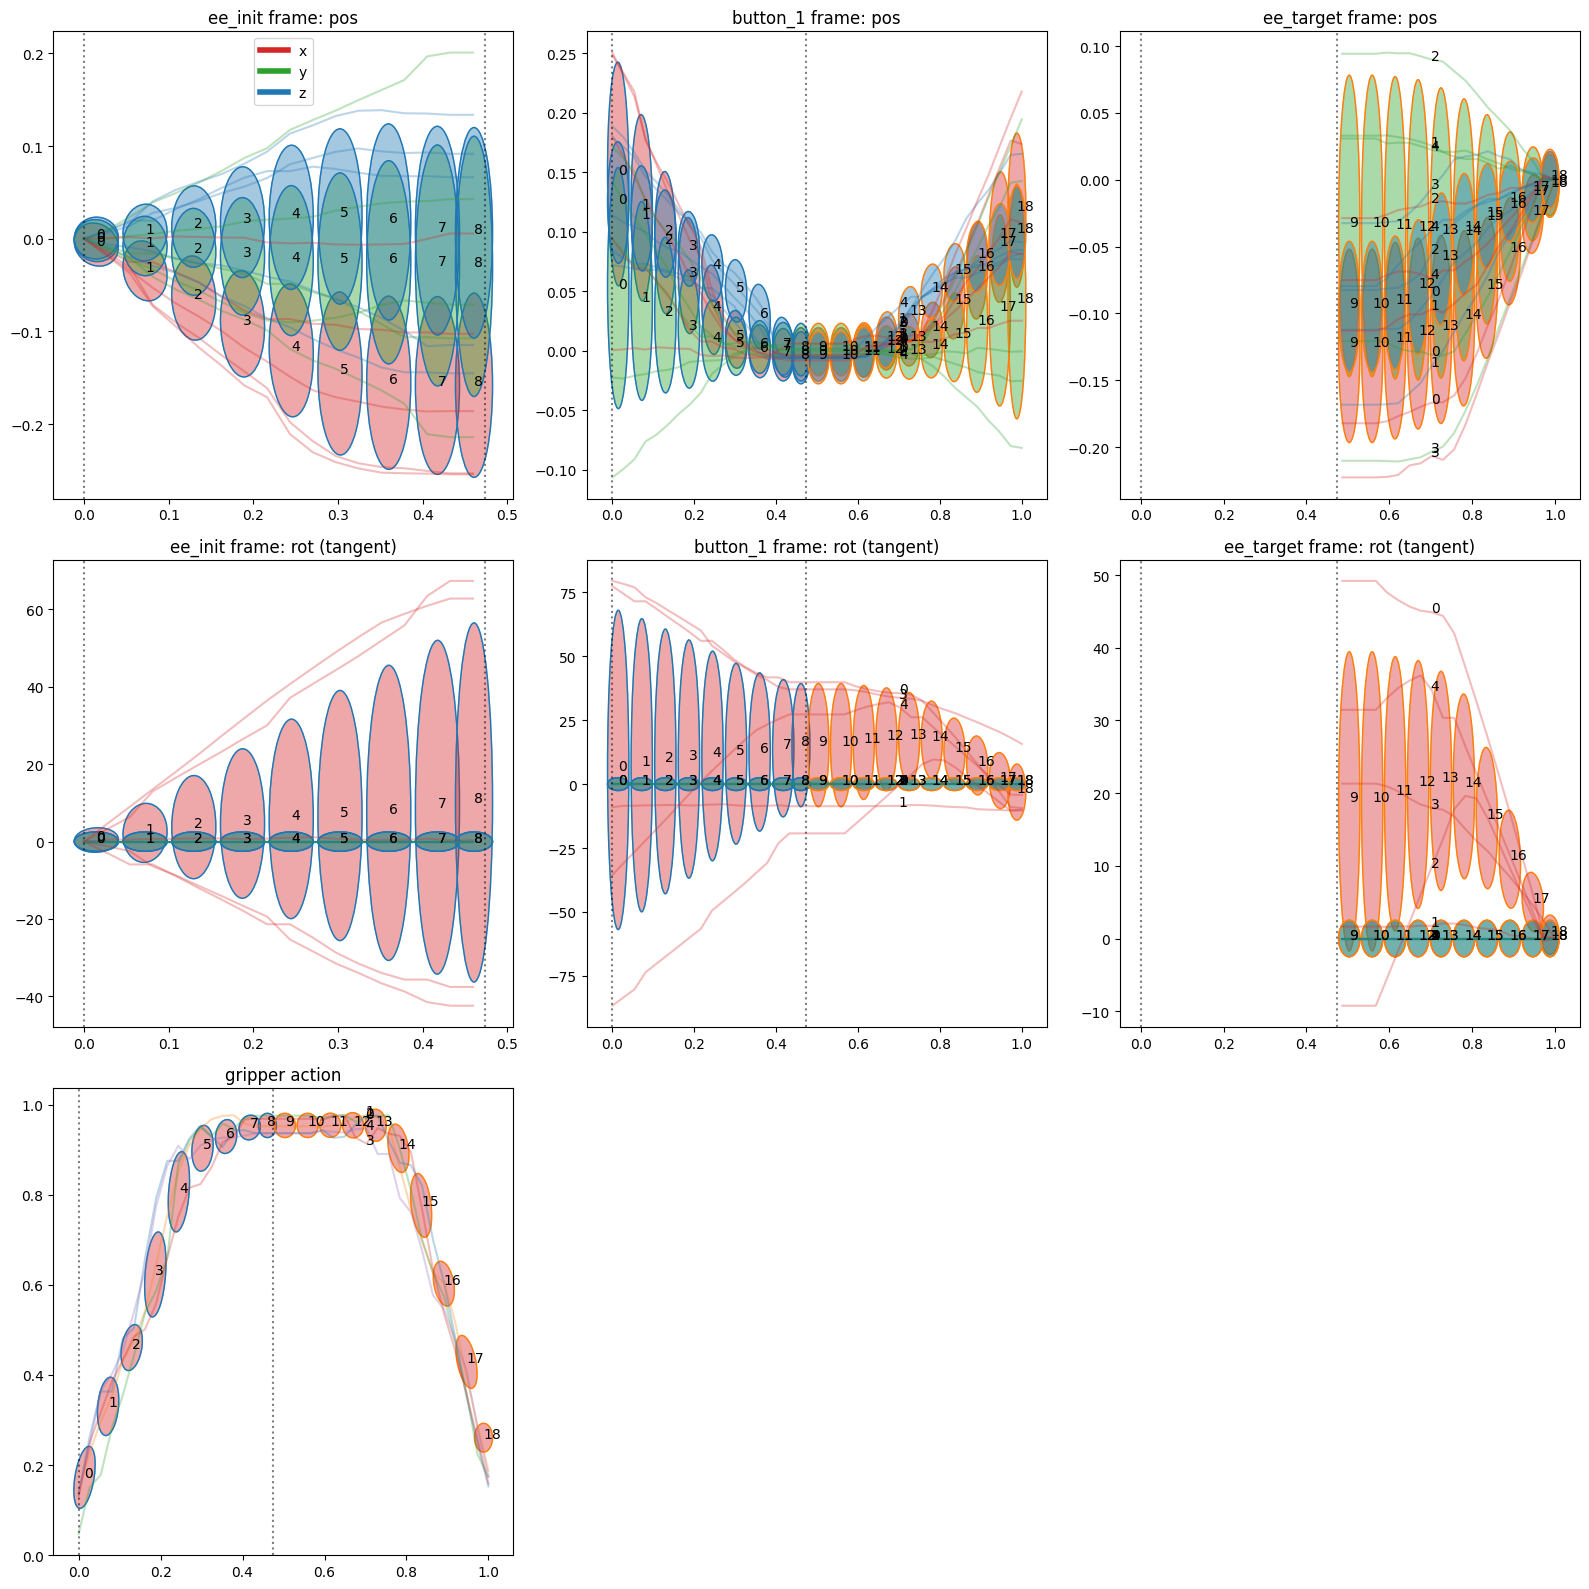

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


2026-07-07 02:35:23.756 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 02:35:23.756 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-07 02:35:23.759 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:35:23.760 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:35:23.762 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:35:23.789 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:35:32.794 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 02:35:32.825 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 02:35:32.825 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 02:35:32.828 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 02:35:32.848 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 02:35:51.441 | WARNING  | riepybdlib.statistics:em:2262 - HMM EM did not converge


((array([[1.00e+000, 9.84e-001, 1.09e-002, 1.25e-008, 4.34e-024, 3.06e-051,
          4.26e-092, 9.14e-146, 2.29e-213, 3.35e-303, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.27e-001, 7.07e-002, 1.55e-006, 3.33e-017, 3.07e-038,
          2.99e-072, 1.65e-120, 1.86e-183, 1.74e-259, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.87e-001, 4.47e-003, 3.99e-017, 1.92e-046, 6.41e-100,
          2.20e-185, 1.81e-299, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 1.00e+000, 1.00e+000, 1.58e-006, 8.43e-023, 4.23e-051,
          5.22e-097, 7.79e-171, 1.05e-278, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          1.00e+000, 9.96e-001, 4.99e-004, 8.33e-016, 2.93e-044, 9.37e-095,
          2.

2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 02:35:51.524 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippi

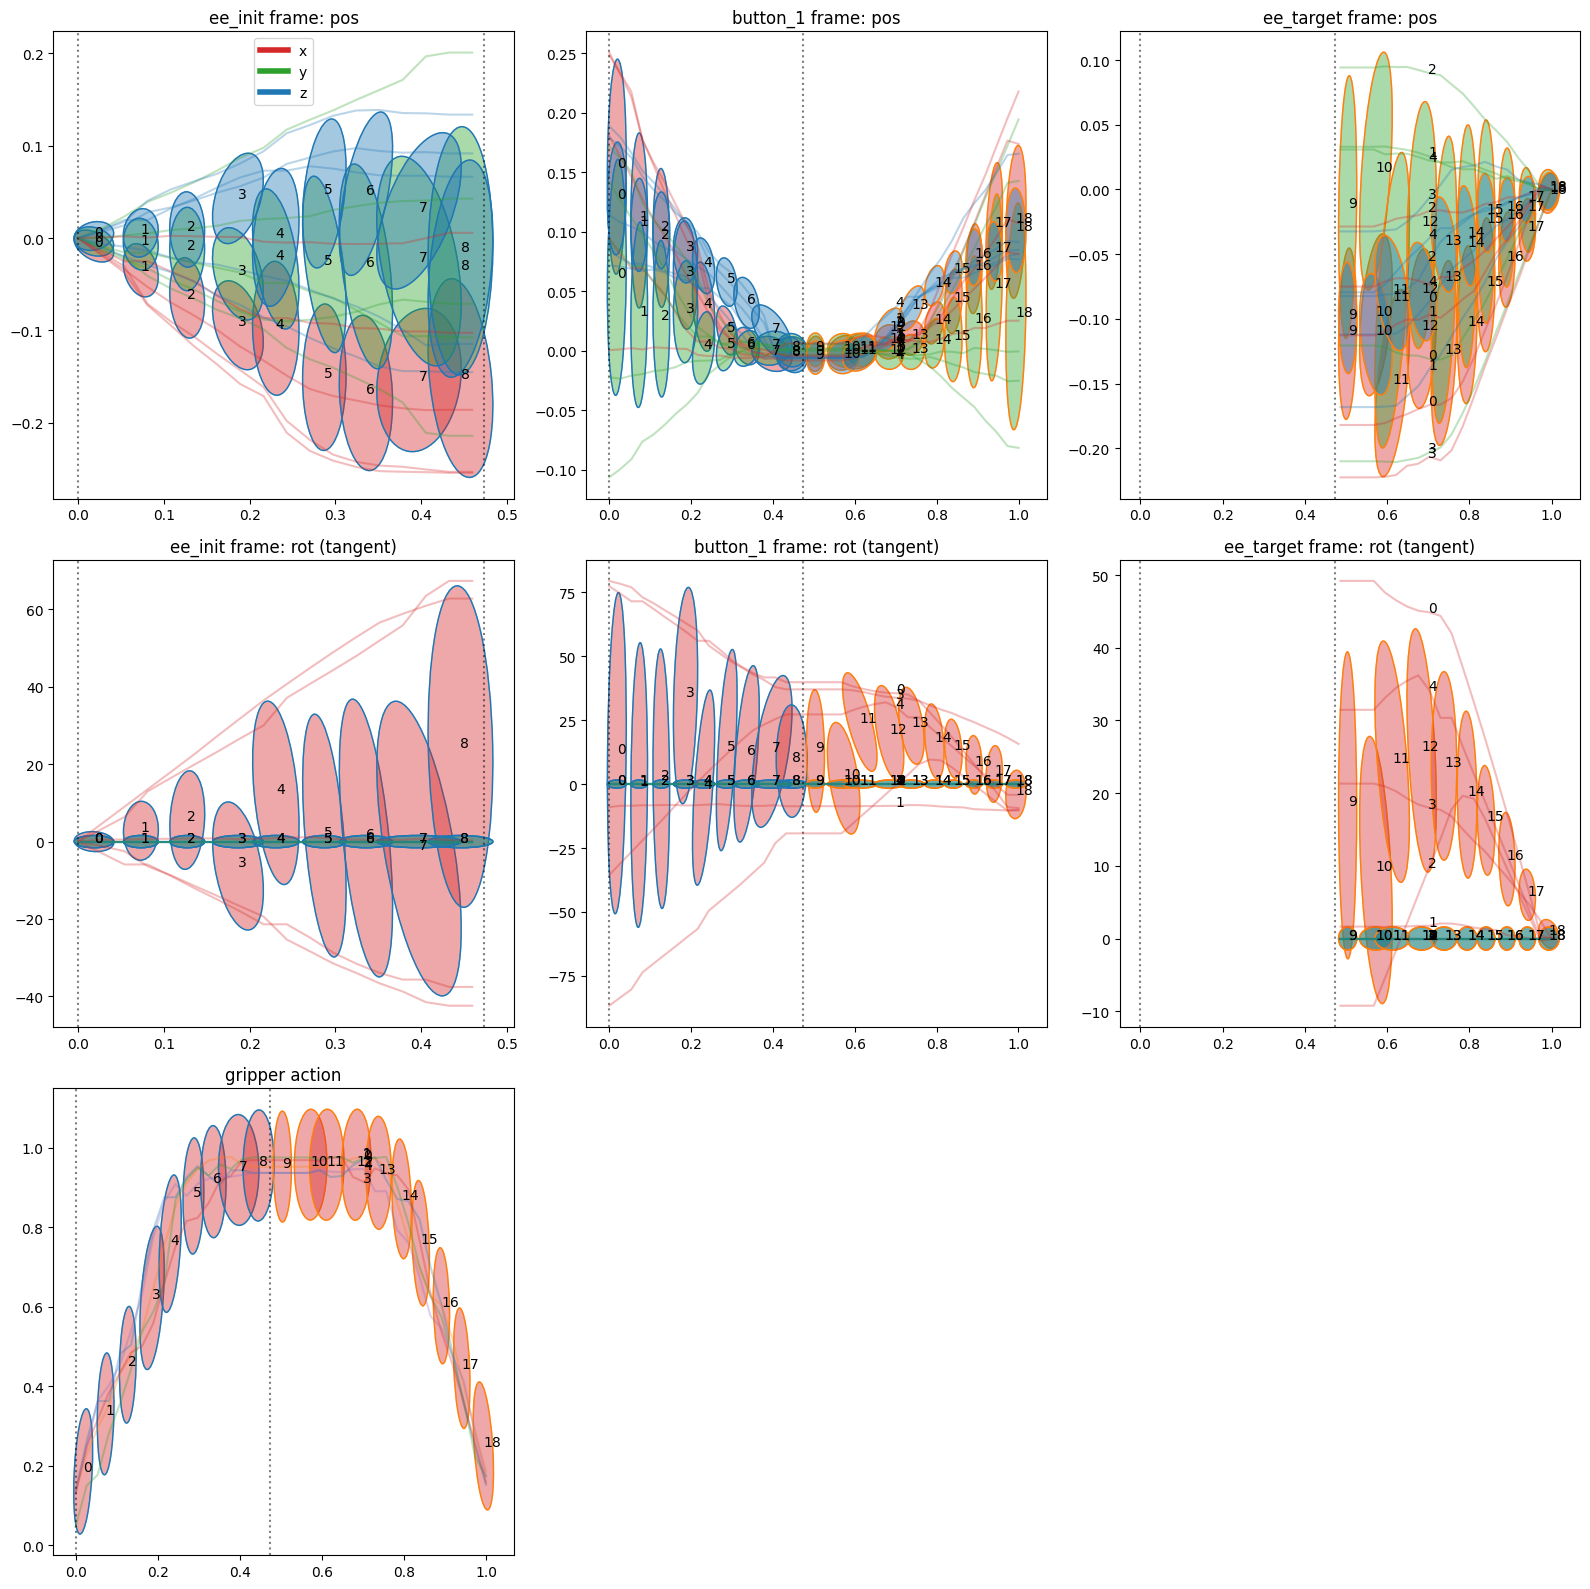

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

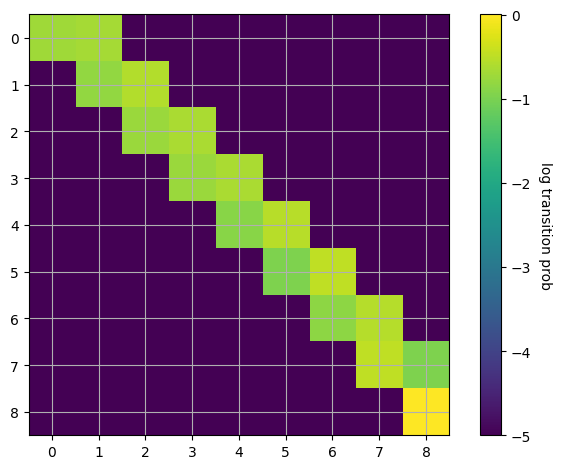

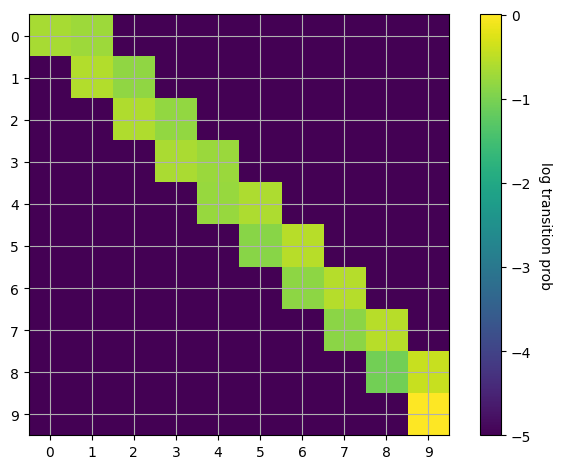

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
agent.save()

2026-07-07 02:35:53.840 | INFO     | heca.misc.logger:info:30 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_right_button
2026-07-07 02:35:53.840 | INFO     | heca.misc.logger:info:30 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/lock_right_button/policy_gt.pt
2026-07-07 02:35:53.840 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [10]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


2026-07-07 02:35:53.901 | INFO     | tapas_gmm_modified.policy.models.tpgmm:reconstruct:3239 - Time-based reconstruction not specified. Auto selected True.
2026-07-07 02:36:01.961 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_cascade_segment_hmms:3343 - Caculated segment transition probabilities: (array([[0.02]]),)
2026-07-07 02:36:01.961 | WARNING  | tapas_gmm_modified.policy.models.tpgmm:_cascade_segment_hmms:3349 - At least one segment transition prob below 5%. Can lead to problems.Consider increasing the diag reg.
2026-07-07 02:36:01.961 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:36:01.961 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
2026-07-07 02:36:01.963 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity. Should be fixed.
2026-07-07 02:36:01.963 | INFO     |

Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:01.968 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.971 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.974 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.977 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.980 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.983 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.985 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.988 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:01.992 | INFO     | riepybdlib.statistics:set_n

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:02.002 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.045 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.055 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.065 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.075 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.086 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 02:36:02.087 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 38 using strategy mean-length.
2026-07-07 02:36:02.088 | INFO     | tapas_gmm_modified.dataset.demos:_frame_quats2world_velocities:807 - Assuming zero frame velocity.

...

2026-07-07 02:36:02.098 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.102 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.106 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.109 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.113 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.116 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.119 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.123 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.126 | INFO     | riepybdlib.statisti

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:02.142 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.190 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.202 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.213 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.225 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.237 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:02.237 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:02.238 | WARNING  | riepybdlib.statistics:__init__:2454 - Setting init priors of later segments to zero.
2026-07-07 02:36:02.238 | WARNING  | riepybd

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

2026-07-07 02:36:02.249 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.249 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:02.698 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:02.699 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:03.138 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:03.138 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:03.537 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 02:36:03.537 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 02:36:03.894 | INFO     | riepybdlib.statistics:s

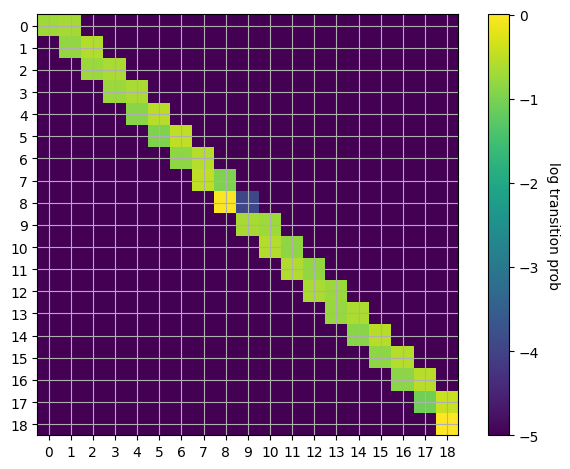

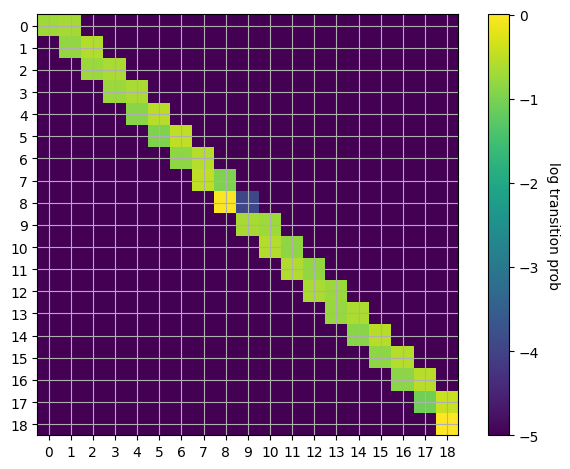

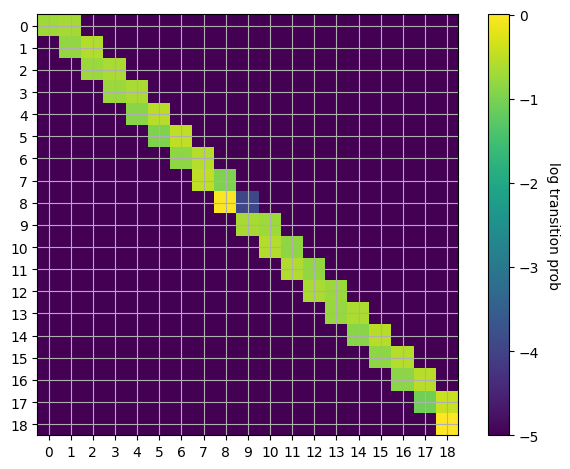

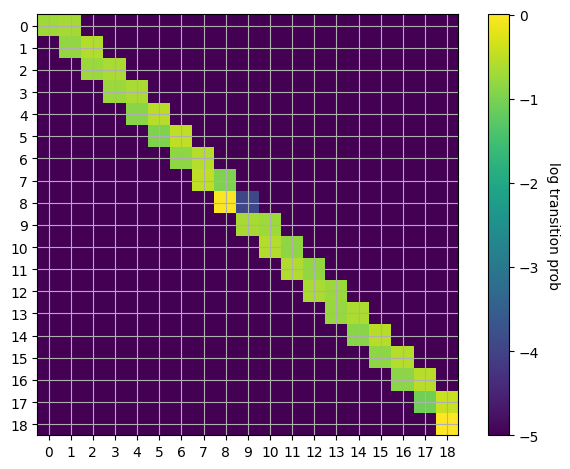

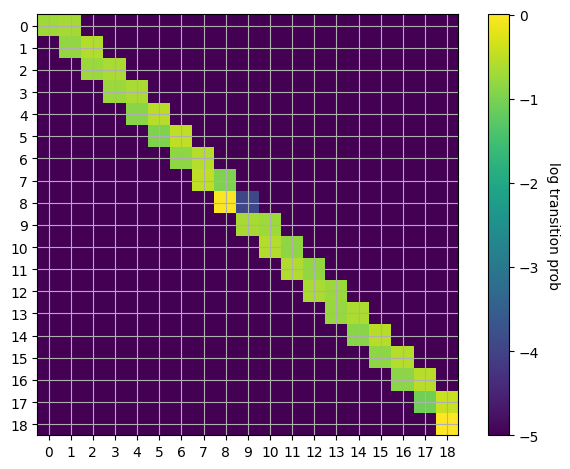

In [11]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2026-07-07 02:36:05.039 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_plot_reconstructions_jointly:4105 - Taking frame origins from demos.


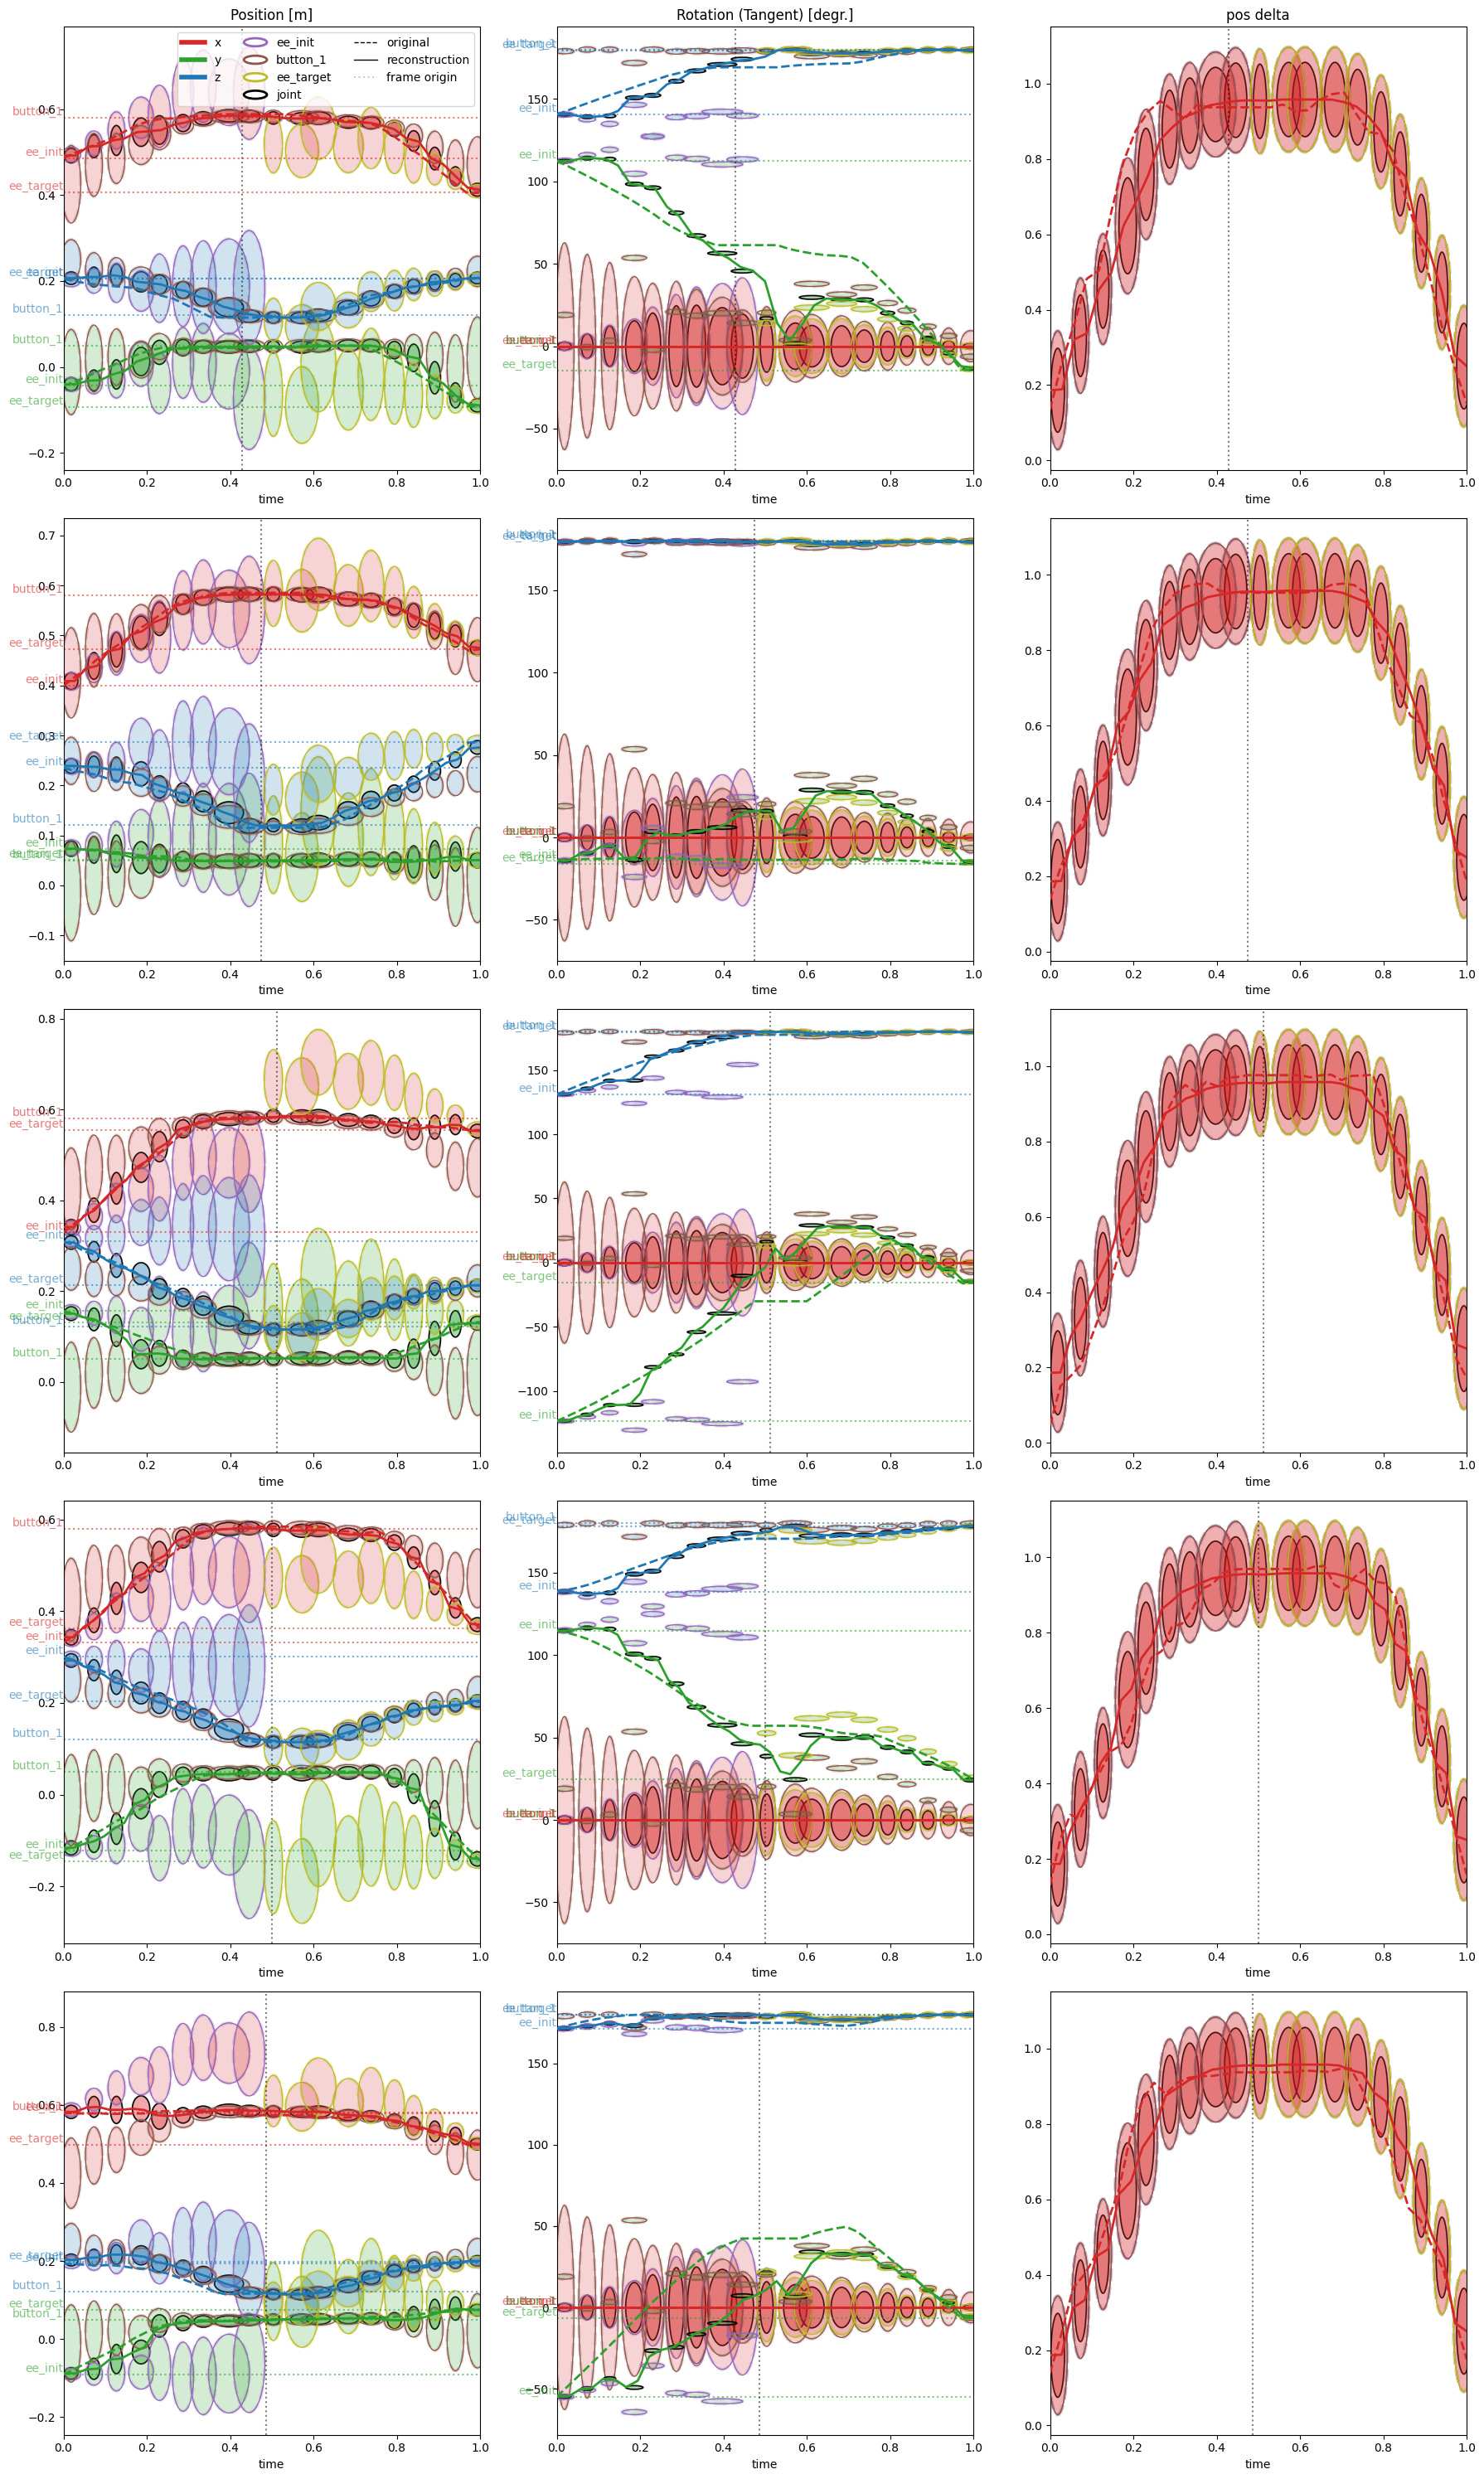

In [12]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [13]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range